In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv('C:\\Users\\Администратор\\Documents\\study\\APS\\notebooks\\df_model_aps_data.csv')
df.head()

,id,referral_date,open_date,number_of_days_open,disposition_status_description,prior_aps_history_before_2022,age_at_time_of_referral,gender,race,marital_status_description,...,duration,main_id,first_open_date,time_since_first_open,reoccurred_6m,reoccurred_6_12m,reoccurred_12_24m,reoccurred_24m_plus,total_case_count,closed_date
0,987679398-2,2024-09-04,2024-09-04,15.0,CLOSED,Y,80.0,M,Caucasian/White,Single-Never Married,...,15 days,987679398,2024-09-04,0.0,False,False,False,False,2,2024-09-19
1,987679482-1,2022-03-01,2022-03-01,45.0,CLOSED,N,57.0,M,Caucasian/White,Married-Living Together,...,45 days,987679482,2022-03-01,0.0,False,False,False,False,10,2022-04-15
2,987679482-3,2023-02-13,2023-02-13,59.0,CLOSED,N,58.0,M,Caucasian/White,Single-Never Married,...,59 days,987679482,2022-03-01,349.0,False,True,False,False,10,2023-04-13
3,987679482-7,2024-10-09,2024-10-09,29.0,CLOSED,N,NaN,M,Caucasian/White,Married-Living Together,...,29 days,987679482,2022-03-01,953.0,False,False,False,True,10,2024-11-07
4,987679506-1,2024-10-31,2024-10-31,50.0,CLOSED,N,56.0,F,Caucasian/White,Married-Living Together,...,50 days,987679506,2024-10-31,0.0,False,False,False,False,1,2024-12-20


In [26]:
df.columns.to_list()

['id',
 'referral_date',
 'open_date',
 'number_of_days_open',
 'disposition_status_description',
 'prior_aps_history_before_2022',
 'age_at_time_of_referral',
 'gender',
 'race',
 'marital_status_description',
 'veteran_ind',
 'housing_arrangement',
 'does_client_live_alone',
 'alleged_harm_self_neglect',
 'investigation_harm_self_neglect',
 'alleged_harm_neglect',
 'investigation_harm_neglect',
 'alleged_harm_financial_exploitation',
 'investigation_harm_financial_exploitation',
 'alleged_harm_exploitation_of_person',
 'investigation_harm_exploitation_of_person',
 'alleged_harm_physical_abuse',
 'investigation_harm_physical_abuse',
 'alleged_harm_emotional_abuse',
 'investigation_harm_emotional_abuse',
 'alleged_harm_sexual_abuse',
 'investigation_harm_sexual_abuse',
 'alleged_harm_abandonment',
 'investigation_harm_abandonment',
 'alleged_vulnerability_advanced_age_frailty_dependency',
 'alleged_vulnerability_cognitive_impairment',
 'alleged_vulnerability_developmental_intellectual_

In [7]:
all_columns = df.columns.to_list()

alleged_cols = [col for col in all_columns if col.startswith('alleged_')]
investigation_cols = [col for col in all_columns if col.startswith('investigation_')]
verified_cols = [col for col in all_columns if col.startswith('verified_')]
client_risk_cols = [col for col in all_columns if col.startswith('client_intial_risk')]
environmental_cols = [col for col in all_columns if col.startswith('environmental_intial_risk')]
support_network_cols = [col for col in all_columns if col.startswith('support_network_intial_risk')]
caregiver_cols = [col for col in all_columns if col.startswith('caregiver_intial_risk')]
perpetrator_cols = [col for col in all_columns if col.startswith('perpetrator_intial_risk')]

# Adding demographic, case info, and outcome/reoccurrence columns
demographic_cols = ['age_at_time_of_referral', 'gender', 'race', 'marital_status_description', 'housing_arrangement',  'veteran_ind']

case_info_cols = ['id', 'main_id', 'referral_date', 'open_date', 'first_open_date', 'number_of_days_open',
                  'duration', 'time_since_first_open', 'disposition_status_description',
                  'prior_aps_history_before_2022', 'total_case_count',
                  'does_client_live_alone', 'live_with_ind', 'primary_caregiver_ind', 'perpetrator_type_desc']

reoccurrence_cols = [col for col in all_columns if col.startswith('reoccurred_')]

# Combine all specific columns to find the 'other' columns
categorized_cols = set(alleged_cols + investigation_cols + verified_cols + client_risk_cols + environmental_cols + \
                       support_network_cols + caregiver_cols + perpetrator_cols + demographic_cols + case_info_cols + reoccurrence_cols)

other_cols = [col for col in all_columns if col not in categorized_cols]

print(f"Alleged columns: {len(alleged_cols)}")
print(f"Investigation columns: {len(investigation_cols)}")
print(f"Verified columns: {len(verified_cols)}")
print(f"Client risk columns: {len(client_risk_cols)}")
print(f"Environmental columns: {len(environmental_cols)}")
print(f"Support network columns: {len(support_network_cols)}")
print(f"Caregiver columns: {len(caregiver_cols)}")
print(f"Perpetrator columns: {len(perpetrator_cols)}")
print(f"Demographic columns: {len(demographic_cols)}")
print(f"Case Info columns: {len(case_info_cols)}")
print(f"Reoccurrence columns: {len(reoccurrence_cols)}")
print(f"Other columns: {len(other_cols)}")
print(f"\nRemaining 'other' columns: {other_cols}")

Alleged columns: 14
Investigation columns: 8
Verified columns: 6
Client risk columns: 14
Environmental columns: 9
Support network columns: 6
Caregiver columns: 10
Perpetrator columns: 4
Demographic columns: 6
Case Info columns: 15
Reoccurrence columns: 4
Other columns: 1

Remaining 'other' columns: ['closed_date']


In [8]:
df[all_columns].dtypes.value_counts()

object     88
bool        4
float64     3
int64       2
Name: count, dtype: int64

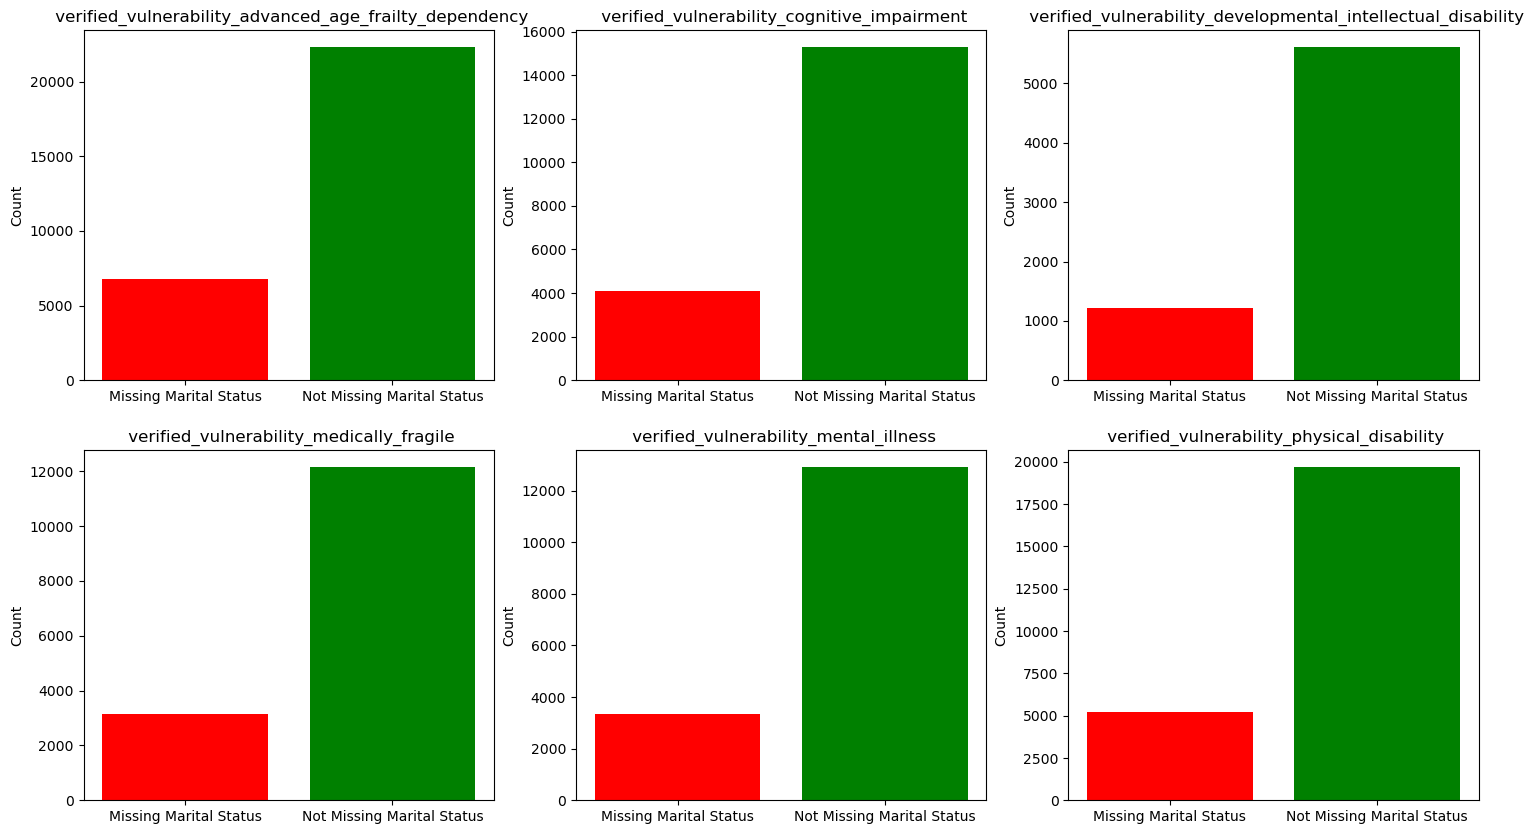

In [37]:
# visualizing missing marital status by verified cols

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(verified_cols[:6]):
    ax = axes[i // 3, i % 3]
    df_temp = df[df[col] == 'Y']
    missing_marital_status = df_temp['marital_status_description'].isna().sum()
    not_missing_marital_status = df_temp['marital_status_description'].notna().sum()
    ax.bar(['Missing Marital Status', 'Not Missing Marital Status'], [missing_marital_status, not_missing_marital_status], color=['red', 'green'])
    ax.set_title(f' {col}')
    ax.set_ylabel('Count')

In [ ]:
# Create a flag to indicate if marital status is missing
df['marital_status_missing'] = df['marital_status_description'].isna()

print("--- Numeric Columns by Marital Status Missingness ---")
# Compare averages of numerical columns
numeric_comparison = df.groupby('marital_status_missing')[['age_at_time_of_referral', 'total_case_count', 'number_of_days_open']].mean()
display(numeric_comparison)

print("\n--- % Missing Marital Status by Gender ---")
# Compare proportions for categorical columns
gender_missing = df.groupby('gender')['marital_status_missing'].mean() * 100
display(gender_missing.to_frame('% Missing Marital Status'))

print("\n--- % Missing Marital Status by Verified Mental Illness ---")
mental_illness_missing = df.groupby('verified_vulnerability_mental_illness')['marital_status_missing'].mean() * 100
display(mental_illness_missing.to_frame('% Missing Marital Status'))

print("\n--- % Missing Marital Status by Reoccurrence (6 months) ---")
reoccurred_missing = df.groupby('event_next')['marital_status_missing'].mean() * 100
display(reoccurred_missing.to_frame('% Missing Marital Status'))

--- Numeric Columns by Marital Status Missingness ---


,age_at_time_of_referral,total_case_count,number_of_days_open
marital_status_missing,,,
False,65.464101,3.443921,67.215116
True,67.700477,2.985235,63.507444



--- % Missing Marital Status by Gender ---


,% Missing Marital Status
gender,
F,21.914709
M,21.499362
O,50.000000
U,92.000000



--- % Missing Marital Status by Verified Mental Illness ---


,% Missing Marital Status
verified_vulnerability_mental_illness,
N,22.347329
Y,20.596373



--- % Missing Marital Status by Reoccurrence (6 months) ---


,% Missing Marital Status
reoccurred_6m,
False,22.255445
True,17.323748


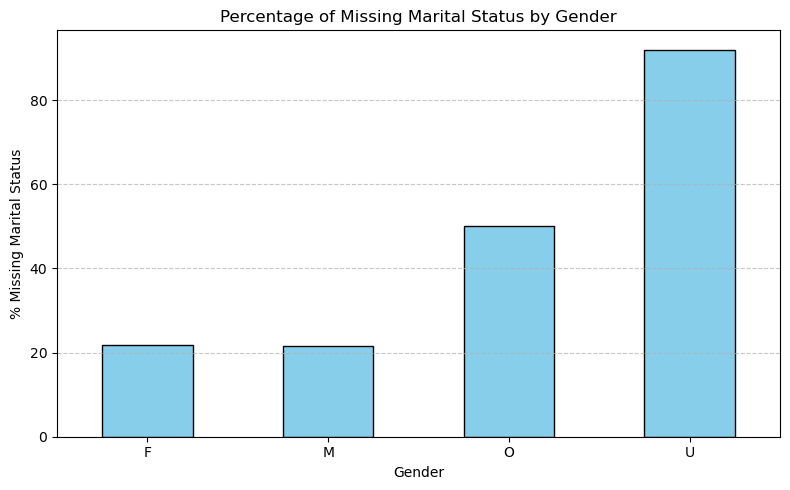

In [14]:
import matplotlib.pyplot as plt

# Plotting the percentage of missing marital status by gender
plt.figure(figsize=(8, 5))
gender_missing.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Percentage of Missing Marital Status by Gender')
plt.xlabel('Gender')
plt.ylabel('% Missing Marital Status')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

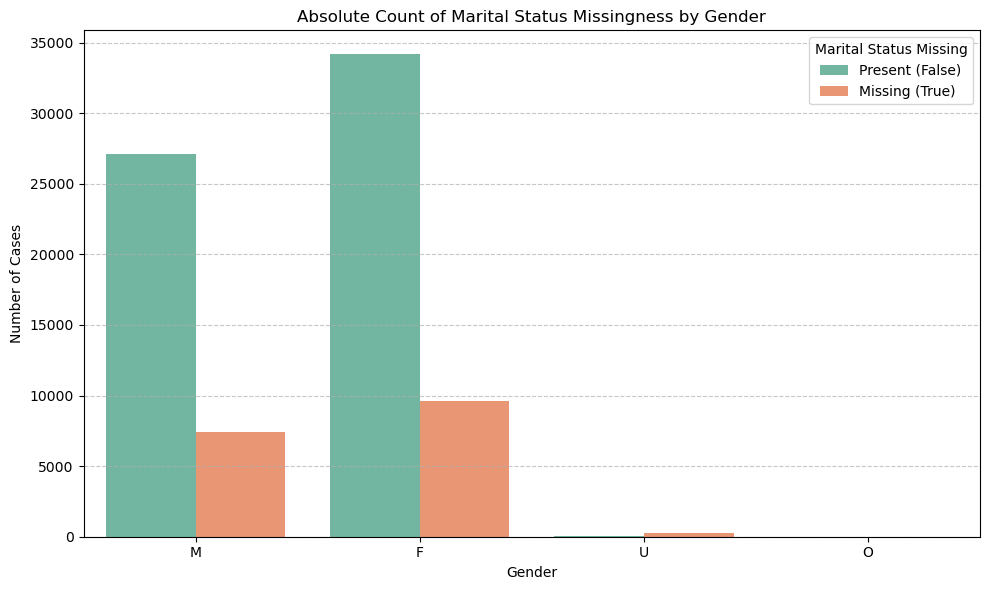

--- Absolute Counts of Missing Marital Status by Gender ---


,Present,Missing,Total,% Missing
gender,,,,
F,34167,9589,43756,21.914709
M,27089,7419,34508,21.499362
O,10,10,20,50.000000
U,22,253,275,92.000000


In [15]:
import seaborn as sns

# Visualize absolute counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='gender', hue='marital_status_missing', palette='Set2')
plt.title('Absolute Count of Marital Status Missingness by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Cases')
plt.legend(title='Marital Status Missing', labels=['Present (False)', 'Missing (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the actual numerical counts
print("--- Absolute Counts of Missing Marital Status by Gender ---")
counts_by_gender = df.groupby(['gender', 'marital_status_missing']).size().unstack(fill_value=0)
counts_by_gender.columns = ['Present', 'Missing']
counts_by_gender['Total'] = counts_by_gender['Present'] + counts_by_gender['Missing']
counts_by_gender['% Missing'] = (counts_by_gender['Missing'] / counts_by_gender['Total']) * 100
display(counts_by_gender)

In [16]:
# 1. Isolate ONLY the "Seen" clients (Male and Female)
seen_clients = df[df['gender'].isin(['F', 'M'])]

# 2. Split them into our two groups
has_status = seen_clients[~seen_clients['marital_status_description'].isna()]
missing_status = seen_clients[seen_clients['marital_status_description'].isna()]

print("--- PROFILING THE 16,000 MISSING M/F CASES ---")

# 3. Test the Cognitive Hypothesis (Are they more confused?)
cog_col = 'client_intial_risk_confused' # Or 'client_intial_risk_prior_or_current_cognitive_issues'
print(f"\n1. Severe Cognitive Confusion '{cog_col}' (Proportion '3' or '4'):")
has_cog = has_status[cog_col].value_counts(normalize=True)
miss_cog = missing_status[cog_col].value_counts(normalize=True)
has_cog_val = (has_cog.get('3', 0) + has_cog.get('4', 0)) * 100
miss_cog_val = (miss_cog.get('3', 0) + miss_cog.get('4', 0)) * 100
print(f"Has Status: {has_cog_val:.1f}%")
print(f"Missing Status: {miss_cog_val:.1f}%")

# 4. Test the Physical Crisis Hypothesis (Do they need severe help to survive?)
crisis_col = 'client_intial_risk_needs_assistance_with_adls_and_or_iadls'
print(f"\n2. Physical Crisis '{crisis_col}' (Proportion '3' or '4'):")
has_crisis = has_status[crisis_col].value_counts(normalize=True)
miss_crisis = missing_status[crisis_col].value_counts(normalize=True)
has_crisis_val = (has_crisis.get('3', 0) + has_crisis.get('4', 0)) * 100
miss_crisis_val = (miss_crisis.get('3', 0) + miss_crisis.get('4', 0)) * 100
print(f"Has Status: {has_crisis_val:.1f}%")
print(f"Missing Status: {miss_crisis_val:.1f}%")

--- PROFILING THE 16,000 MISSING M/F CASES ---

1. Severe Cognitive Confusion 'client_intial_risk_confused' (Proportion '3' or '4'):
Has Status: 13.7%
Missing Status: 13.3%

2. Physical Crisis 'client_intial_risk_needs_assistance_with_adls_and_or_iadls' (Proportion '3' or '4'):
Has Status: 24.9%
Missing Status: 22.6%


In [17]:
print("Unique values in 'client_intial_risk_confused':")
display(df['client_intial_risk_confused'].value_counts(dropna=False))

print("\nUnique values in 'client_intial_risk_needs_assistance_with_adls_and_or_iadls':")
display(df['client_intial_risk_needs_assistance_with_adls_and_or_iadls'].value_counts(dropna=False))

Unique values in 'client_intial_risk_confused':


client_intial_risk_confused
2      26618
1      25479
N      13133
3       8929
I       2155
4       1635
NaN      610
Name: count, dtype: int64


Unique values in 'client_intial_risk_needs_assistance_with_adls_and_or_iadls':


client_intial_risk_needs_assistance_with_adls_and_or_iadls
2      32072
1      16543
3      16433
N       8536
4       2576
I       1789
NaN      610
Name: count, dtype: int64

--- % Missing Marital Status by Referral Year ---


,% Missing
referral_year,
2022,24.750666
2023,21.262008
2024,19.944849


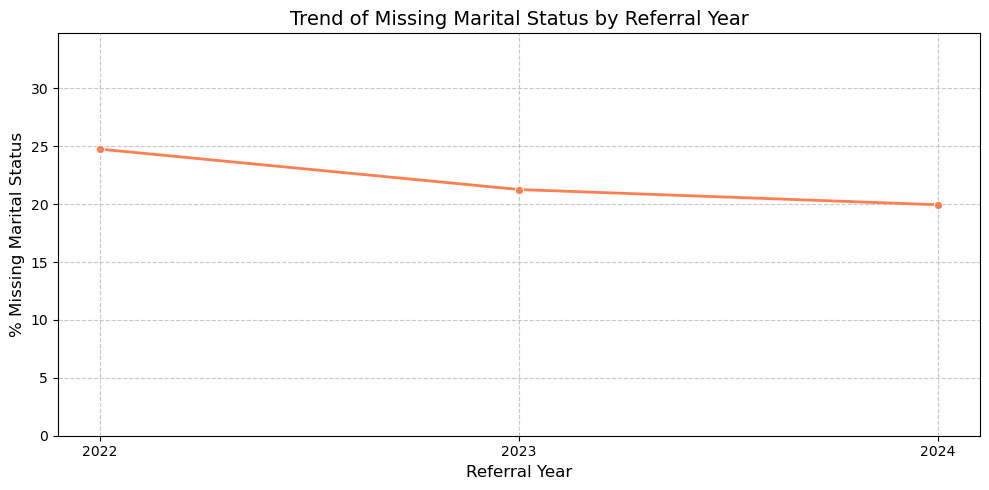

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the year from the referral_date
df['referral_year'] = pd.to_datetime(df['referral_date']).dt.year

# Calculate the percentage of missing marital status per year
missing_by_year = df.groupby('referral_year')['marital_status_missing'].mean() * 100

print("--- % Missing Marital Status by Referral Year ---")
display(missing_by_year.to_frame('% Missing'))

# Visualize the trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=missing_by_year.index, y=missing_by_year.values, marker='o', linewidth=2, color='coral')

# Formatting the plot
plt.title('Trend of Missing Marital Status by Referral Year', fontsize=14)
plt.xlabel('Referral Year', fontsize=12)
plt.ylabel('% Missing Marital Status', fontsize=12)
plt.xticks(missing_by_year.index) # Ensure all years are labeled
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, max(missing_by_year.values) + 10) # Add some padding to the y-axis
plt.tight_layout()
plt.show()

In [19]:
print("--- % Missing Marital Status by Disposition Status ---")
disposition_missing = df.groupby('disposition_status_description')['marital_status_missing'].mean() * 100
display(disposition_missing.sort_values(ascending=False).to_frame('% Missing'))

print("\n--- % Missing Marital Status by Perpetrator Type ---")
perp_type_missing = df.groupby('perpetrator_type_desc')['marital_status_missing'].mean() * 100
display(perp_type_missing.sort_values(ascending=False).to_frame('% Missing'))

--- % Missing Marital Status by Disposition Status ---


,% Missing
disposition_status_description,
OPEN,22.222222
CLOSED,21.984641



--- % Missing Marital Status by Perpetrator Type ---


,% Missing
perpetrator_type_desc,
Residential Staff,30.320700
Other,27.250720
Unrelated Caregiver,26.448215
Paid Caregiver,23.437500
Adult Child,23.369369
Significant Other,21.991178
Self,21.212947
Other Relative,20.102052
Parent,13.125000


--- Detailed Breakdown by Perpetrator Type ---


,total_cases,missing_count,missing_percentage
perpetrator_type_desc,,,
Residential Staff,343,104,30.320700
Other,8675,2364,27.250720
Unrelated Caregiver,8545,2260,26.448215
Paid Caregiver,256,60,23.437500
Adult Child,11100,2594,23.369369
Significant Other,1587,349,21.991178
Self,33027,7006,21.212947
Other Relative,9407,1891,20.102052
Parent,640,84,13.125000


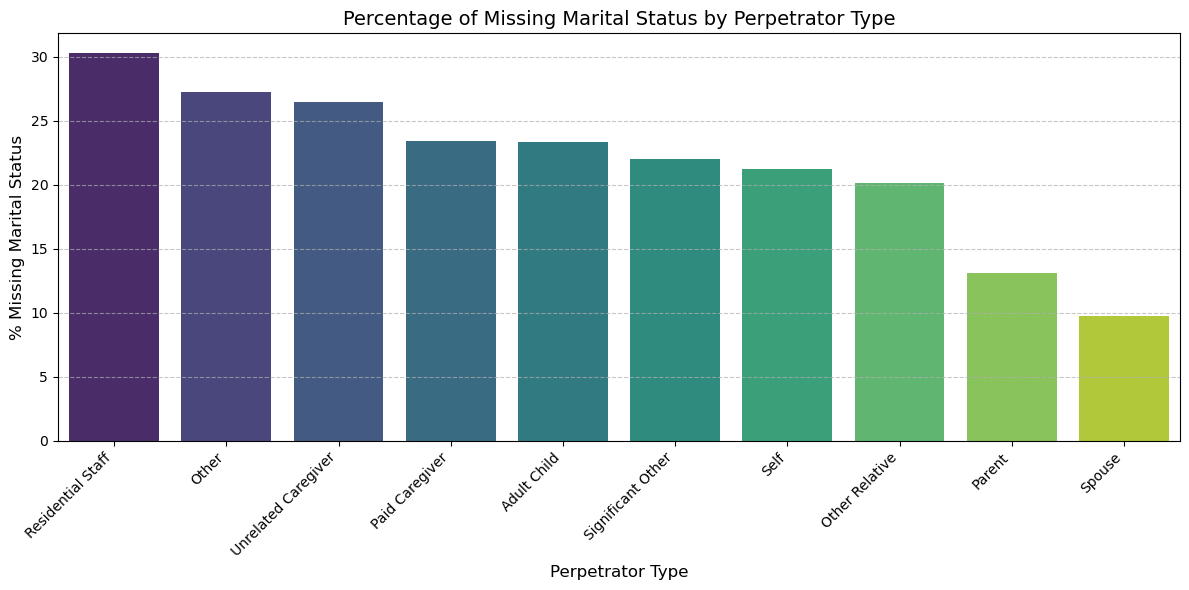

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a summary dataframe with total cases, missing cases, and missing percentage
perp_stats = df.groupby('perpetrator_type_desc').agg(
    total_cases=('marital_status_missing', 'count'),
    missing_count=('marital_status_missing', 'sum'),
    missing_percentage=('marital_status_missing', lambda x: x.mean() * 100)
).sort_values('missing_percentage', ascending=False)

print("--- Detailed Breakdown by Perpetrator Type ---")
display(perp_stats)

# Visualize the missing percentages
plt.figure(figsize=(12, 6))
sns.barplot(x=perp_stats.index, y=perp_stats['missing_percentage'], hue=perp_stats.index, palette='viridis', legend=False)

# Formatting the plot
plt.title('Percentage of Missing Marital Status by Perpetrator Type', fontsize=14)
plt.xlabel('Perpetrator Type', fontsize=12)
plt.ylabel('% Missing Marital Status', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Why does "Self" explain the majority of the missingness?
- A client who is the perpetrator of their own severe neglect is often in the most extreme state of vulnerability possible.

- They are often entirely isolated (meaning there is no caregiver or family member for the investigator to ask about their demographics).

- They are frequently suffering from advanced dementia, severe untreated mental illness (like schizophrenia), or extreme physical degradation.

- They are often living in unsafe conditions (hoarding, lack of utilities, squalor).

In [21]:
df['marital_status_description'].value_counts()

marital_status_description
Single-Never Married       26881
Widowed                    13399
Married-Living Together    10026
Divorced                    8814
Married-Separated           2060
Domestic Partner             101
Unknown                        7
Name: count, dtype: int64

## MISSINGNESS IMPUTATION

In [22]:
df_model = df.copy()

In [23]:
# Rule-based imputation for Spouses
mask = (df_model['perpetrator_type_desc'] == 'Spouse') & (df_model['marital_status_description'].isna())
# Note: If you haven't filled with 'Unknown' yet, use .isna() instead of == 'Unknown'

df_model.loc[mask, 'marital_status_description'] = 'Married-Living Together'

print(f"Successfully imputed 'Married' for {mask.sum()} cases.")

Successfully imputed 'Married' for 447 cases.


In [24]:
# # 1. Fill the rest of the missing marital statuses with 'Unknown'
# df_model['marital_status_description'] = df_model['marital_status_description'].fillna('Unknown')

# print("Current counts for Marital Status:")
# display(df_model['marital_status_description'].value_counts())

# # 2. Check what other columns still have missing values
# print("\n--- Remaining Missing Values in df_model ---")
# remaining_missing = df_model.isna().sum()
# remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
# display(remaining_missing)

In [25]:
# dropping the reoccurence columns and changing it into event,
# which only shows the reoccurence of the event.
# df_model = df_model.drop(columns=reoccurrence_cols)
